In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from os.path import curdir

In [14]:
# Question 1a

xl_path = os.path.join(curdir, 'Data', '860_Assignment1_Data_vf.xlsx')

# Loading the specific sheet, skipping the first 16 rows
island_airport_weather = pd.read_excel(
    xl_path, 
    sheet_name='Island Airport Weather', 
    header=16  # Row 17 is index 16
)

# Preview the data
#island_airport_weather.head()

# Validate Type
#island_airport_weather.dtypes

In [15]:
# Question 1a continued

# Calculate air density using the provided formula
# Formula: (Stn Press * 1000) / (287.05 * (Temp + 273.15))
island_airport_weather['Air_Density'] = (island_airport_weather['Stn Press (kPa)'] * 1000) / (287.05 * (island_airport_weather['Temp (°C)'] + 273.15))

# Print out the first 5 records to show your answer snippet
island_airport_weather[['Stn Press (kPa)', 'Temp (°C)', 'Air_Density']].head()

,Stn Press (kPa),Temp (°C),Air_Density
0,98.49,4.3,1.236659
1,98.47,5.1,1.232853
2,98.57,5.9,1.230567
3,98.98,3.3,1.247307
4,99.29,2.8,1.253480


In [16]:
# Question 1b

# Convert wind speed from km/h to m/s
island_airport_weather['Wind_Spd_ms'] = island_airport_weather['Wind Spd (km/h)'] * 0.277778

# Print out the first 5 records to show your answer snippet
island_airport_weather[['Wind Spd (km/h)', 'Wind_Spd_ms']].head()

,Wind Spd (km/h),Wind_Spd_ms
0,11,3.055558
1,4,1.111112
2,28,7.777784
3,34,9.444452
4,28,7.777784


In [20]:
# Question 1c

# Loading the specific sheet
turbine_specs = pd.read_excel(
    xl_path, 
    sheet_name='Turbine Specifications'
)

# Preview the data
turbine_specs.head()

# Validate Type
#turbine_specs.dtypes

,Field,Comments,Values,Units
0,Wind facility name/ID,The name of the wind facility,Toronto Wind One,NaN
1,Number of turbines,Number of turbines at this facility,49,NaN
2,Cut-in windspeed (m/s),The minimum wind speed needed for the turbine ...,4,m/s
3,Cut-out windspeed (m/s),The maximum wind speed at which the turbine wi...,32,m/s
4,Maximum power coefficient,"Generally accepted to be from 0.25 to 0.45, us...",0.35,NaN


In [25]:
# Question 1c continued

# 1. Extract and convert values from turbine_specs
cut_in = pd.to_numeric(turbine_specs.loc[turbine_specs['Field'] == 'Cut-in windspeed (m/s)', 'Values'].values[0])
cut_out = pd.to_numeric(turbine_specs.loc[turbine_specs['Field'] == 'Cut-out windspeed (m/s)', 'Values'].values[0])
max_cp = pd.to_numeric(turbine_specs.loc[turbine_specs['Field'] == 'Maximum power coefficient', 'Values'].values[0])
swept_area = pd.to_numeric(turbine_specs.loc[turbine_specs['Field'] == 'Turbine swept area', 'Values'].values[0])
nominal_power_mw = pd.to_numeric(turbine_specs.loc[turbine_specs['Field'] == 'Turbine nominal power', 'Values'].values[0])
nominal_power_watts = nominal_power_mw * 1000000

# print(cut_in)
# print(cut_out)
# print(max_cp)
# print(swept_area)
# print(nominal_power_mw)
# print(nominal_power_watts)

# 2. Calculate the baseline power using the formula
# power = Air_Density * Swept_Area * 0.5 * (Wind_Spd_ms^3) * Max_Cp
island_airport_weather['Power_Watts'] = island_airport_weather['Air_Density'] * swept_area * 0.5 * (island_airport_weather['Wind_Spd_ms'] ** 3) * max_cp

# 3. Apply the constraints using np.where
# Condition 1: If wind is below cut-in OR above cut-out, power is 0
island_airport_weather['Power_Watts'] = np.where(
    (island_airport_weather['Wind_Spd_ms'] < cut_in) | (island_airport_weather['Wind_Spd_ms'] > cut_out), 
    0, 
    island_airport_weather['Power_Watts']
)

# Condition 2: Cap the power at the turbine's nominal maximum capacity
island_airport_weather['Power_Watts'] = np.where(
    island_airport_weather['Power_Watts'] > nominal_power_watts, 
    nominal_power_watts, 
    island_airport_weather['Power_Watts']
)

# Print out the first 5 records
island_airport_weather[['Wind_Spd_ms', 'Air_Density', 'Power_Watts']].head()

,Wind_Spd_ms,Air_Density,Power_Watts
0,3.055558,1.236659,0.000000e+00
1,1.111112,1.232853,0.000000e+00
2,7.777784,1.230567,1.344892e+06
3,9.444452,1.247307,2.440722e+06
4,7.777784,1.253480,1.369935e+06


In [26]:
# Question 1d

# 1. Sum up the hourly power produced by a single turbine
total_power_single_turbine_watts = island_airport_weather['Power_Watts'].sum()

# 2. Multiply by the 49 turbines in the windfarm
total_windfarm_power_watts = total_power_single_turbine_watts * 49

# 3. Convert the total power from Watts to Megawatts (divide by 1,000,000)
total_windfarm_power_mw = total_windfarm_power_watts / 1000000

# Print the final result
print(f"Total Electricity Produced for the Windfarm in January: {total_windfarm_power_mw:.2f} MW")

Total Electricity Produced for the Windfarm in January: 43077.82 MW


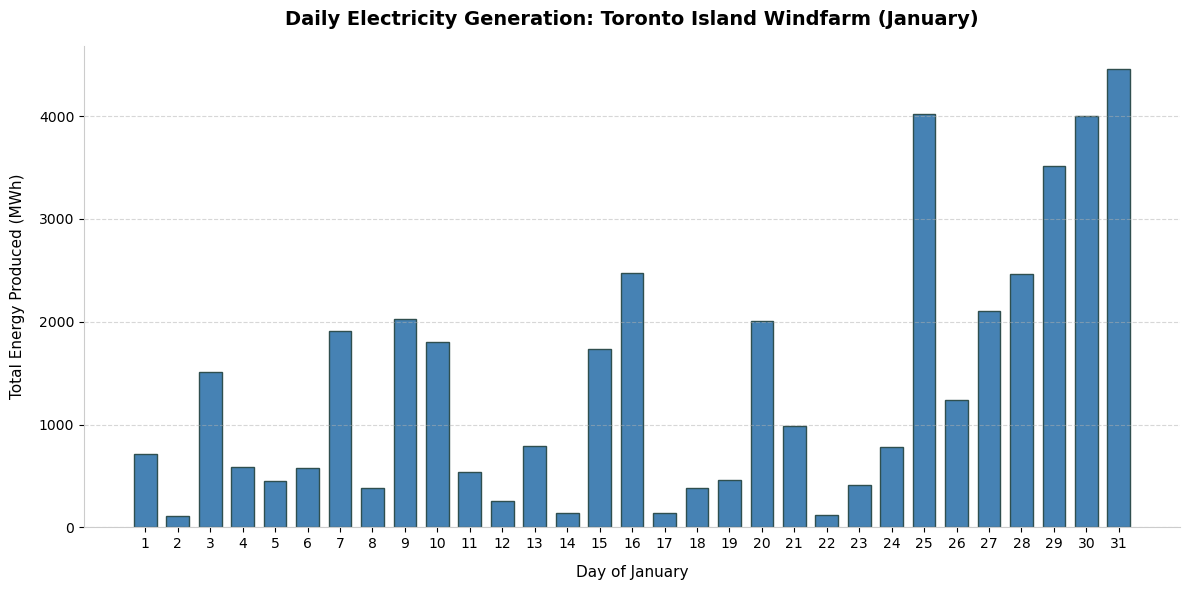

In [29]:
# Question 1e

# 1. Calculate daily windfarm energy production
# Group by the existing 'Day' column, sum the hourly Power_Watts, 
# multiply by 49 turbines, and divide by 1,000,000 to convert to MWh
daily_energy = (island_airport_weather.groupby('Day')['Power_Watts'].sum() * 49) / 1000000

# 2. Create the professional bar chart
# Using subplots to avoid plt.figure() as per best practices
fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars in chronological order (Day 1 to 31) with a professional steel blue color
ax.bar(daily_energy.index, daily_energy.values, color='#4682B4', edgecolor='#2F4F4F', width=0.7)

# Title and Labels
ax.set_title('Daily Electricity Generation: Toronto Island Windfarm (January)', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Day of January', fontsize=11, labelpad=10)
ax.set_ylabel('Total Energy Produced (MWh)', fontsize=11, labelpad=10)

# Clean up chart borders (Spines) to reduce visual clutter
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Add subtle horizontal gridlines for easier value reading
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Ensure the x-axis displays every single day from 1 to 31 clearly without overlapping
ax.set_xticks(daily_energy.index)

# Adjust layout and save the image file
plt.tight_layout()
plt.show()